# Post-processing snapshots

Load and visualize `SimulationState` snapshots written by any RMHD run — whether the run
happened right here on this laptop or on a cluster (e.g. Savio) and the snapshot directory
was copied over afterwards. This notebook replaces the old `load_savio_on_laptop.ipynb`
and `3d_image.ipynb`, both of which used a pre-refactor loading API; see `CLAUDE.md` and
`docs/checkpointing.md` for the current invariants.

**To point this at a different run:** change `snap_path` in the next cell to the run's
snapshot directory (the directory that contains `params.json`, if the run saved one, and
the numbered step subdirectories). Nothing else needs to change as long as the run used
the current `SimulationState`/`snapshot_io` layout.

**Precision:** `RMHD_PRECISION` (env var, default `32`) is read once, at `import jax_rmhd`
time, and fixes FIELD precision (`ftype`/`ctype`) for the rest of the process (`jax_enable_x64` is always on; `t` is always float64). Set it to match the run
*before* importing `jax_rmhd` — loading a float64 snapshot while jax is running in float32
(or vice versa) will not error cleanly, since `Parameters.from_snapshot`/`load_snapshot`
build their `ShapeDtypeStruct` templates from whatever precision is currently active, not
from the snapshot's own `_precision` record (that's only used for a warning). E.g. from a
shell: `RMHD_PRECISION=64 jupyter lab`, or set `os.environ["RMHD_PRECISION"] = "64"` as the
very first line of the very first cell, before `import jax_rmhd`.


## Setup

`snap_path` below defaults to the directory used by `examples/orzag-tang-3d.ipynb`
(`data/ot3d_v3`, relative to the `examples/` directory) — the intended workflow is: run
that notebook first to produce snapshots, then run this one to post-process them.

`Parameters.from_snapshot(snap_path)` reconstructs the exact `Parameters` used for the run
from `snap_path/params.json`, *if* that run called `params.save(snap_path)` at some point
(it's an explicit call — nothing writes `params.json` automatically, see `CLAUDE.md`).
`orzag-tang-3d.ipynb` as currently written does **not** call `params.save`, so for a fresh
run from that notebook the `params.json` path below won't exist and the manual fallback
(commented out, with that notebook's exact parameter values) is used instead. If your run
*did* call `params.save`, delete/ignore the fallback and just use `from_snapshot`.


In [1]:
import os
# If this run used a non-default precision, set RMHD_PRECISION *before* importing jax_rmhd, e.g.:
# os.environ["RMHD_PRECISION"] = "64"

import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as colors

import jax_rmhd.diagnostics as diag

# point this at any run's snapshot directory (local or an rsync'd copy of a cluster run)
snap_path = "data/ot3d_v3"

params_json = os.path.join(snap_path, "params.json")
if os.path.exists(params_json):
    params = jr.Parameters.from_snapshot(snap_path)
else:
    print(f"No {params_json} found (this run did not call params.save) -- "
          f"falling back to a manually constructed Parameters matching "
          f"examples/orzag-tang-3d.ipynb.")
    params = jr.Parameters(
        nx=128, ny=128, nz=128,
        Lx=2.0 * jnp.pi, Ly=2.0 * jnp.pi, Lz=2.0 * jnp.pi,
        eqpars={'diss': (1e-9, 1e-9), 'hyper': 3},
        cfl_safety=0.5, dims=3,
    )

kgrid = jr.setup_kgrids(params)
print(f"params.size={params.size}, dims={params.spatial_dimensions}, "
      f"nx={params.nx}, ny={params.ny}, nz={params.nz}")


jax is using 64bit precision.
params.size=1, dims=3, nx=64, ny=64, nz=64


## Load the latest snapshot

`get_saved_steps` is a plain directory scan (per `docs/checkpointing.md`: never
`mngr.all_steps()` for reads, and reads never construct a `CheckpointManager` at all —
`load_snapshot` uses a bare `StandardCheckpointHandler` internally).


In [2]:
from jax_rmhd.snapshot_io import get_saved_steps, load_snapshot

steps = get_saved_steps(snap_path)
print(f"found {len(steps)} saved snapshot(s): {steps}")

isnap = steps[-1]
state = load_snapshot(isnap, snap_path, params)
print(f"loaded snapshot {isnap} at t={float(state.t):.4f}, fields shape {state.fields.shape}")


found 2 saved snapshot(s): [0, 1]
loaded snapshot 1 at t=5.0093, fields shape (2, 64, 64, 33)


## 2D slices: vorticity and current density

`state.fields[0]` is `phi`, `state.fields[1]` is `psi`. Vorticity
$\zeta = \nabla_\perp^2\phi$ and current density $j = \nabla_\perp^2\psi$ are both
$-k_\perp^2 \times$ the field in Fourier space; `irfft2` brings them back to real space.
`iz` below indexes into the *local* z-slab held by `state.fields` (the full `params.nz`
range only if this snapshot was loaded on a single process -- `comm_backend="serial"`, the
laptop default with no MPI installed, or `"mpi4jax"`/`"jax"` with `params.size==1`, which is
the common post-processing case).


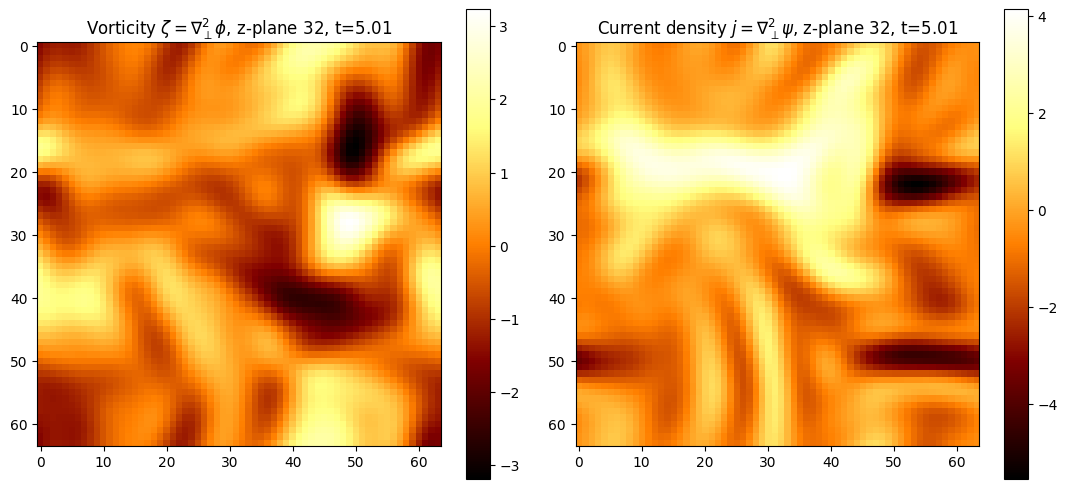

In [3]:
iz = params.nz // 2  # z-plane to plot; any 0 <= iz < state.fields.shape[1]

vort = ft.irfft2(-kgrid.ksq * state.fields[0])  # (nz, nx, ny) vorticity, real space
curr = ft.irfft2(-kgrid.ksq * state.fields[1])  # (nz, nx, ny) current density, real space

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

im0 = axes[0].imshow(vort[iz], cmap="afmhot")
axes[0].set_title(rf"Vorticity $\zeta=\nabla_\perp^2\phi$, z-plane {iz}, t={float(state.t):.2f}")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(curr[iz], cmap="afmhot")
axes[1].set_title(rf"Current density $j=\nabla_\perp^2\psi$, z-plane {iz}, t={float(state.t):.2f}")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


## Perpendicular energy spectrum

`diagnostics.perpspec` returns the z-averaged perpendicular energy spectra of `u` (from
`phi`) and `b` (from `psi`), already normalized consistently with `diagnostics.energy` and
`forcing_power` (see `CLAUDE.md`'s note on the shared `perp_*` normalization convention).
The dashed line is a $k_\perp^{-5/3}$ reference, anchored at the first nonzero bin of
$E_u$.


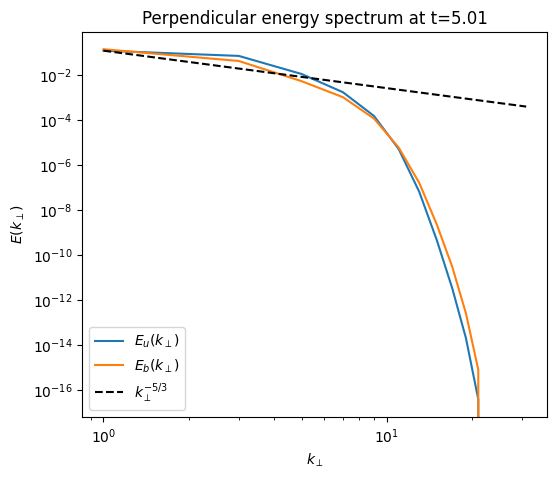

In [4]:
bins, su, sb = diag.perpspec(state, kgrid, params)

plt.figure(figsize=(6, 5))
plt.loglog(bins, su, label=r'$E_u(k_\perp)$')
plt.loglog(bins, sb, label=r'$E_b(k_\perp)$')

nonzero = su > 0
if jnp.any(nonzero):
    k0 = bins[nonzero][0]
    e0 = su[nonzero][0]
    plt.loglog(bins, e0 * (bins / k0) ** (-5.0 / 3.0), 'k--', label=r'$k_\perp^{-5/3}$')

plt.xlabel(r'$k_\perp$')
plt.ylabel(r'$E(k_\perp)$')
plt.legend()
plt.title(f"Perpendicular energy spectrum at t={float(state.t):.2f}")
plt.show()


## 3D rendering: three visible cube faces

The three-visible-face vorticity rendering from the old `3d_image.ipynb`, generalized away
from its hardcoded `N=256`/single `L`: `plot_vorticity_cube` below reads the grid size off
the data itself (`data.shape[0]`) and takes the box length as a parameter
(`params.Lx`), so it works at whatever resolution/box size the loaded run used. Like the
original, it assumes a cubic-ish domain (`nx == ny == nz`, `Lx == Ly == Lz`) — true for
every current example (Orszag-Tang, forced turbulence) but worth knowing if you point this
at something anisotropic.

This renders a single frame from the snapshot loaded above. To make movie frames across a
whole run, loop over `get_saved_steps(snap_path)` and call `load_snapshot` + this function
once per step (see `examples/forced-turbulence-3D.ipynb`'s "Vorticity frames across the
run" cell for the pattern, incl. writing PNGs and assembling a GIF) — commented sketch
below.


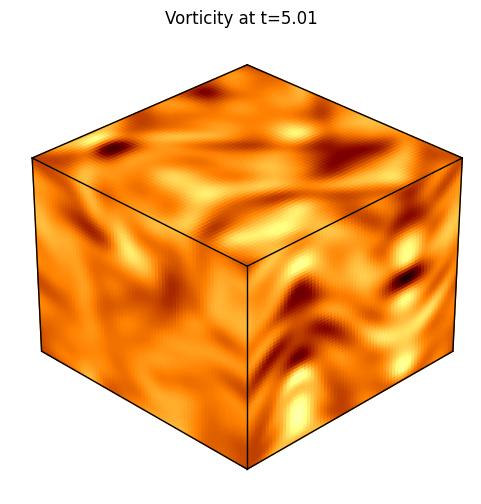

In [5]:
def plot_vorticity_cube(data, L, title=None, vscale=None):
    '''3-face cube plot of a real-space 3D field, e.g. vorticity, shape (nz,nx,ny).
    Adapted from the old examples/3d_image.ipynb; generalized to read the grid size off
    the data instead of a hardcoded N, and to take the box length L as a parameter.
    Assumes a cubic-ish domain (nx==ny==nz, Lx==Ly==Lz).'''
    data = np.asarray(data)
    N = data.shape[0]
    if vscale is None:
        vscale = float(np.max(np.abs(data)))
    norm = colors.Normalize(vmin=-vscale, vmax=vscale)
    color_data_XY = cm.afmhot(norm(data[N - 1, :, :]))
    color_data_XZ = cm.afmhot(norm(data[:, :, N - 1]))
    color_data_YZ = cm.afmhot(norm(data[:, N - 1, :]))

    coords = np.linspace(0, L, N)
    X, Y = np.meshgrid(coords, coords, indexing='ij')

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(np.full_like(X, L), X, Y, facecolors=color_data_XY, shade=False, rstride=1, cstride=1)
    ax.plot_surface(X, np.full_like(X, L), Y, facecolors=color_data_YZ, shade=False, rstride=1, cstride=1)
    ax.plot_surface(X, Y, np.full_like(X, L), facecolors=color_data_XZ, shade=False, rstride=1, cstride=1)

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_zlim(0, L)
    ax.view_init(elev=30, azim=45)
    ax.set_axis_off()

    edges = [
        ([0, L], [L, L], [L, L]), ([0, L], [0, 0], [L, L]), ([0, L], [L, L], [0, 0]),
        ([0, 0], [0, L], [L, L]), ([L, L], [0, L], [0, 0]), ([L, L], [0, L], [L, L]),
        ([L, L], [0, 0], [0, L]), ([L, L], [L, L], [0, L]), ([0, 0], [L, L], [0, L]),
    ]
    for xe, ye, ze in edges:
        ax.plot(xe, ye, ze, 'k', linewidth=1, zorder=10)

    if title:
        ax.set_title(title)
    return fig, ax


vort_full = ft.irfft2(-kgrid.ksq * state.fields[0])           # (nz, nx, ny)
vort_full = jnp.roll(vort_full, params.nz // 2, axis=0)        # center the box

fig, ax = plot_vorticity_cube(vort_full, float(params.Lx), title=f"Vorticity at t={float(state.t):.2f}")
plt.show()

# To make movie frames across the whole run instead of a single snapshot:
#
# frames_dir = os.path.join(snap_path, "gif_frames")
# os.makedirs(frames_dir, exist_ok=True)
# vscale = float(jnp.max(jnp.abs(vort_full)))
# for i, isnap_i in enumerate(get_saved_steps(snap_path)):
#     snap_i = load_snapshot(isnap_i, snap_path, params)
#     vort_i = jnp.roll(ft.irfft2(-kgrid.ksq * snap_i.fields[0]), params.nz // 2, axis=0)
#     fig_i, _ = plot_vorticity_cube(vort_i, float(params.Lx),
#                                     title=f"t={float(snap_i.t):.2f}", vscale=vscale)
#     fig_i.savefig(os.path.join(frames_dir, str(i).zfill(4) + ".png"))
#     plt.close(fig_i)
# os.system(f'magick -delay 15 -loop 0 "{frames_dir}"/*.png "{os.path.join(snap_path, "vorticity.gif")}"')


## Using this with cluster (e.g. Savio) data

To post-process a run that happened on a cluster:

1. `rsync` (or `scp -r`) the run's snapshot directory from the cluster to this machine,
   including `params.json` if the run saved one (`rsync -av user@savio:/path/to/snap_dir/
   ./data/some_run/`). For an `mpi4jax` run with `params.size > 1`, this is a directory of
   numbered rank subdirectories (`snap_dir/0/`, `snap_dir/1/`, ...) — `rsync` the whole
   tree; `load_snapshot`/`get_saved_steps` auto-detect this "per_rank" layout vs. the
   single-process/`"jax"`-backend "flat" layout (`snapshot_io.snapshot_layout`).
2. Set `snap_path` in the setup cell above to the local copy's path.
3. No MPI toolchain is needed on this machine to read a cluster run's snapshots: reads are
   single-process and `Parameters.from_snapshot` re-resolves the backend locally
   (`"serial"`), ignoring the `comm_backend` the cluster recorded in `params.json`.
4. If `RMHD_PRECISION` on the cluster run differed from this machine's default, set the
   env var before importing `jax_rmhd` (see the note at the top of this notebook).
5. Re-run the notebook from the top. Everything else — `Parameters.from_snapshot`,
   `get_saved_steps`, `load_snapshot`, the plots — is unchanged; none of it is aware of
   whether the run happened locally or was copied in.
